In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim import corpora
import gensim
from gensim.models import CoherenceModel
from tqdm import tqdm

# Load data
grid_df = pd.read_csv("./data/cell_POIcat.csv.gz")
poi_map = pd.read_csv("./data/POI_datacategories.csv", header=None)
df = pd.read_parquet("./data/enriched_human_mobility_100k.parquet")



ArrowMemoryError: malloc of size 7138251200 failed

In [ ]:
zones = ["Arts and Entertainment", "Business and Professional Services",
    "Community and Government", "Dining and Drinking", "Event",
    "Health and Medicine", "Landmarks and Outdoors", "Nightlife Spot",
    "Retail", "Sports and Recreation", "Travel and Transportation"]

zone_mapping = {
       "Food": "Dining and Drinking",
    "Shopping": "Retail",
    "Entertainment": "Arts and Entertainment",
    "Japanese restaurant": "Dining and Drinking",
    "Western restaurant": "Dining and Drinking",
    "Eat all you can restaurant": "Dining and Drinking",
    "Chinese restaurant": "Dining and Drinking",
    "Indian restaurant": "Dining and Drinking",
    "Ramen restaurant": "Dining and Drinking",
    "Curry restaurant": "Dining and Drinking",
    "BBQ restaurant": "Dining and Drinking",
    "Hot pot restaurant": "Dining and Drinking",
    "Bar": "Dining and Drinking",
    "Diner": "Dining and Drinking",
    "Creative cuisine": "Dining and Drinking",
    "Organic cuisine": "Dining and Drinking",
    "Pizza": "Dining and Drinking",
    "Café": "Dining and Drinking",
    "Tea Salon": "Dining and Drinking",
    "Bakery": "Dining and Drinking",
    "Sweets ": "Dining and Drinking",
    "Wine Bar": "Dining and Drinking",
    "Pub": "Dining and Drinking",
    "Disco": "Arts and Entertainment",
    "Beer Garden": "Dining and Drinking",
    "Fast Food": "Dining and Drinking",
    "Karaoke": "Arts and Entertainment", 
    "Cruising": "Travel and Transportation", 
    "Theme Park Restaurant": "Dining and Drinking",
    "Amusement Restaurant": "Dining and Drinking",
    "Other Restaurants": "Dining and Drinking",
    "Glasses": "Retail",
    "Drug Store": "Retail",
    "Electronics Store": "Retail",
    "DIY Store": "Retail",
    "Convenience Store": "Retail",
    "Recycle Shop": "Retail",
    "Interior Shop": "Retail",
    "Sports Store": "Retail",
    "Clothes Store": "Retail",
    "Grocery Store": "Retail",
    "Online Grocery Store": "Retail",
    "Sports Recreation": "Sports and Recreation",
    "Game Arcade": "Arts and Entertainment",
    "Swimming Pool": "Sports and Recreation",
    "Hotel": "Travel and Transportation",
    "Park": "Landmarks and Outdoors",
    "Transit Station": "Travel and Transportation",
    "Parking Area": "Travel and Transportation",
    "Casino": "Arts and Entertainment",
    "Hospital": "Health and Medicine",
    "Pharmacy": "Health and Medicine",
    "Chiropractic": "Health and Medicine",
    "Elderly Care Home": "Community and Government", 
    "Fishing": "Sports and Recreation",
    "School": "Community and Government",
    "Cram School": "Community and Government",
    "Kindergarten": "Community and Government",
    "Real Estate": "Business and Professional Services",
    "Home Appliances": "Retail",
    "Post Office": "Community and Government",
    "Laundry ": "Business and Professional Services",
    "Driving School": "Community and Government",
    "Wedding Ceremony": "Business and Professional Services", 
    "Cemetary": "Community and Government",
    "Bank": "Business and Professional Services",
    "Vet": "Health and Medicine",
    "Hot Spring": "Landmarks and Outdoors",
    "Hair Salon": "Business and Professional Services",
    "Lawyer Office": "Business and Professional Services",
    "Recruitment Office": "Business and Professional Services",
    "City Hall": "Community and Government",
    "Community Center": "Community and Government",
    "Church": "Community and Government",
    "Retail Store": "Retail",
    "Accountant Office": "Business and Professional Services",
    "IT Office": "Business and Professional Services",
    "Publisher Office": "Business and Professional Services",
    "Building Material": "Retail",
    "Gardening": "Retail",
    "Heavy Industry": "Business and Professional Services",
    "NPO": "Community and Government",
    "Utility Copany": "Business and Professional Services",
    "Port": "Travel and Transportation",
    "Research Facility": "Business and Professional Services"
}

grid_df['POI_name'] = (grid_df['POIcategory'] - 1).map(poi_map.iloc[:,0])
grid_df["zone"] = grid_df["POI_name"].map(zone_mapping).fillna("Other")

grid_docs = []
cell_keys = []
for (x, y), g in grid_df.groupby(['x', 'y']):
    tokens = [row['zone'] for _, row in g.iterrows() for _ in range(int(row['POI_count']))]
    if len(tokens) > 0:  # Only non-empty documents
        grid_docs.append(tokens)
        cell_keys.append((x, y))

print(f"Total documents: {len(grid_docs)}")
print(f"Sample document: {grid_docs[0][:10]}")

dictionary = corpora.Dictionary(grid_docs)
for z in zones:
    if z not in dictionary.token2id:
        dictionary.add_documents([[z]])

corpus = [dictionary.doc2bow(doc) for doc in grid_docs]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")


In [5]:
# Coherence and Perplexity

def compute_metrics(corpus, dictionary, limit=12):

    perplexity_values = []
    model_list = []
    
    for num_topics in tqdm(range(2, limit + 1), desc="Computing metrics"):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10, 
            iterations=50,
            alpha='auto',
            eta='auto',
            per_word_topics=True
        )
        model_list.append(model)
        
        # Perplexity
        perplexity = model.log_perplexity(corpus)
        perplexity_values.append(perplexity)

        print(f"Topics: {num_topics}, Perplexity: {perplexity:.4f}")
    return range(2, limit + 1), perplexity_values, model_list

topic_range, perplexity_vals, models = compute_metrics(
    corpus, dictionary = dictionary
)
# Coherence_UMass
coherence_values = []
for num_topics in tqdm(range(2, 13), desc="U_MASS coherence"):
    model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=50
    )
    cm = CoherenceModel(
        model=model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass'
    )
    
    coherence = cm.get_coherence()
    coherence_values.append(coherence)
        
    print(f"Topics: {num_topics}, U_MASS: {coherence:.4f}")
    
    



Computing metrics:   9%|▉         | 1/11 [00:13<02:17, 13.78s/it]

Topics: 2, Perplexity: -1.7783


Computing metrics:  18%|█▊        | 2/11 [00:29<02:15, 15.04s/it]

Topics: 3, Perplexity: -1.7765


Computing metrics:  27%|██▋       | 3/11 [00:45<02:02, 15.35s/it]

...

Topics: 10, U_MASS: -9.3243


U_MASS coherence:  91%|█████████ | 10/11 [04:50<00:33, 33.06s/it]

Topics: 11, U_MASS: -9.3566


U_MASS coherence: 100%|██████████| 11/11 [05:16<00:00, 28.77s/it]

Topics: 12, U_MASS: -9.3428


C:\Users\moham\AppData\Local\Temp\ipykernel_17840\2044810341.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


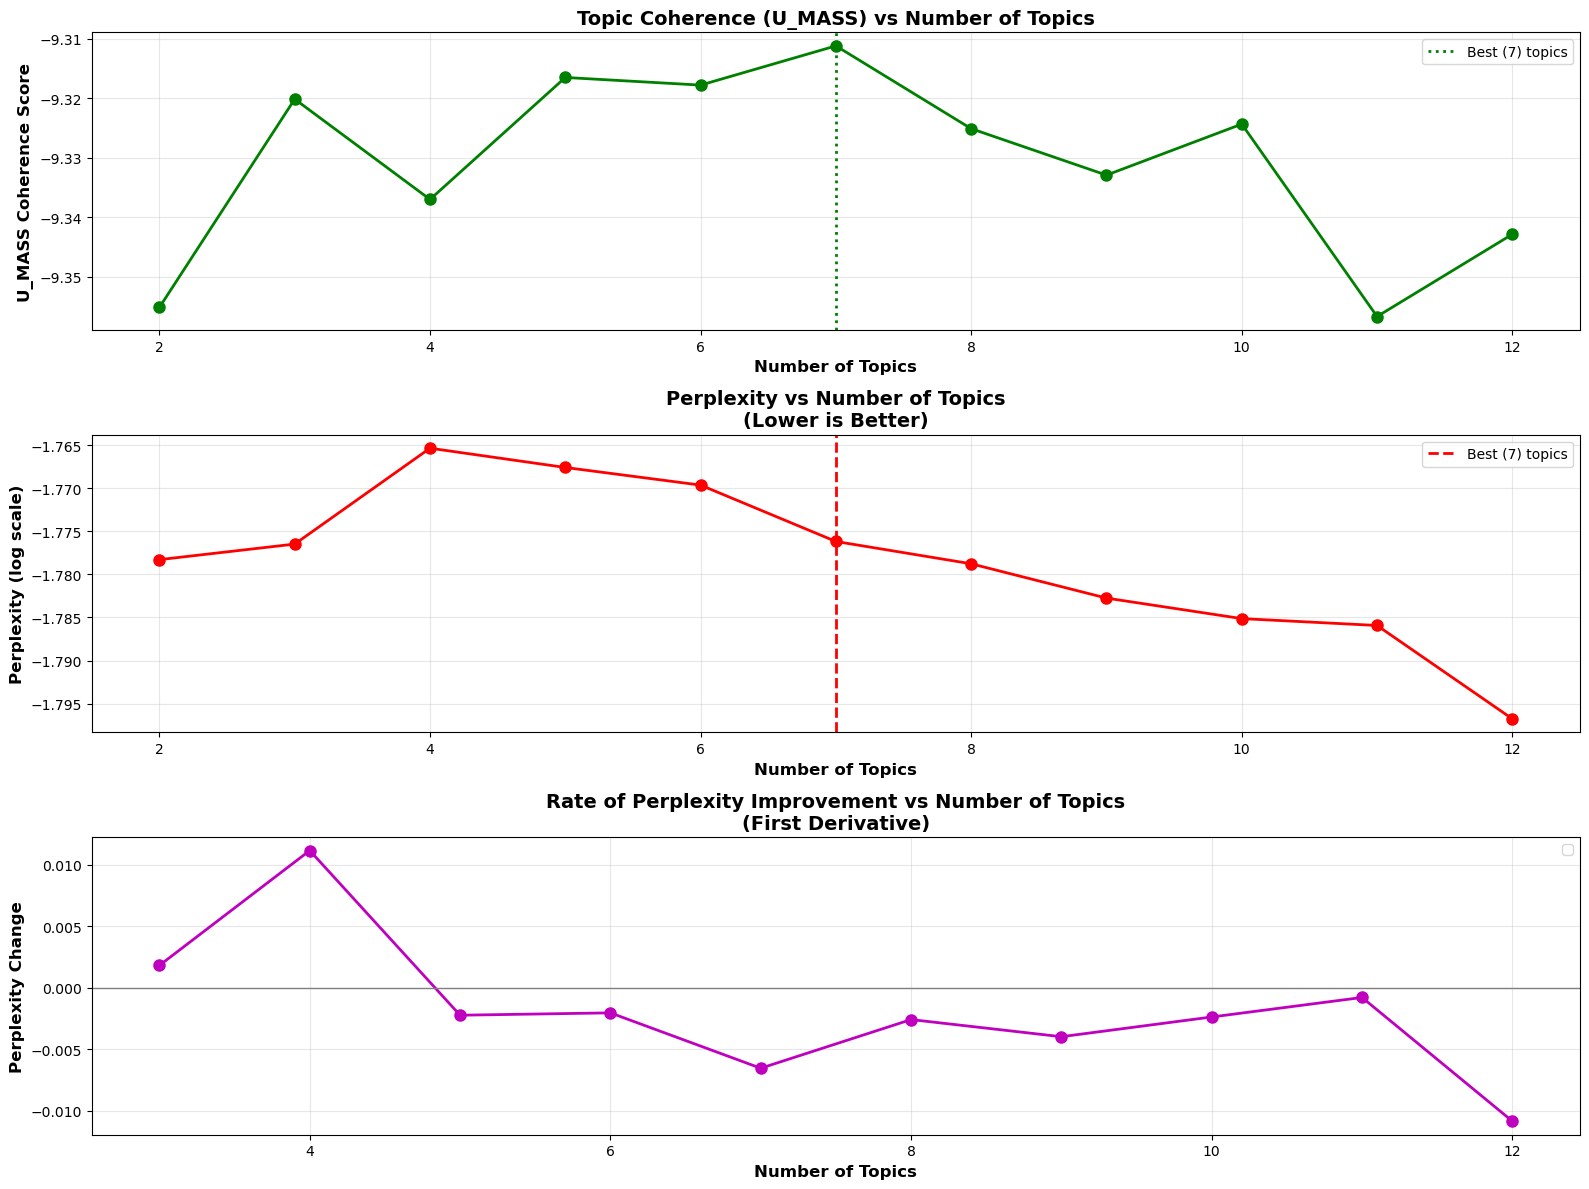

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))


#  U_MASS Coherence (closer to 0 is better)
axes[0].plot(range(2, 13), coherence_values, 'go-', linewidth=2, markersize=8)
max_umass_idx = np.argmax(coherence_values)  # Closer to 0 is better (less negative)
axes[0].axvline(x=max_umass_idx + 2, color='green', linestyle=':', 
                   linewidth=2, label=f'Best ({max_umass_idx + 2}) topics')
axes[0].set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('U_MASS Coherence Score', fontsize=12, fontweight='bold')
axes[0].set_title('Topic Coherence (U_MASS) vs Number of Topics', 
                     fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Perplexity
axes[1].plot(topic_range, perplexity_vals, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=max_umass_idx + 2, color='red', linestyle='--', linewidth=2, label=f'Best ({max_umass_idx + 2}) topics') #Offset by 2 because topic_range starts at 2 
axes[1].set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Perplexity (log scale)', fontsize=12, fontweight='bold')
axes[1].set_title('Perplexity vs Number of Topics\n(Lower is Better)', 
                     fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Rate of change in perplexity
perplexity_diffs = np.diff(perplexity_vals)
axes[2].plot(list(topic_range)[1:], perplexity_diffs, 'mo-', linewidth=2, markersize=8)
axes[2].axhline(y=0, color='gray', linestyle='-', linewidth=1)
axes[2].set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Perplexity Change', fontsize=12, fontweight='bold')
axes[2].set_title('Rate of Perplexity Improvement vs Number of Topics\n(First Derivative)', 
                     fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/topic_selection.png', dpi=300, bbox_inches='tight')
plt.show()

Topic diversity: 100%|██████████| 9/9 [07:26<00:00, 49.63s/it]


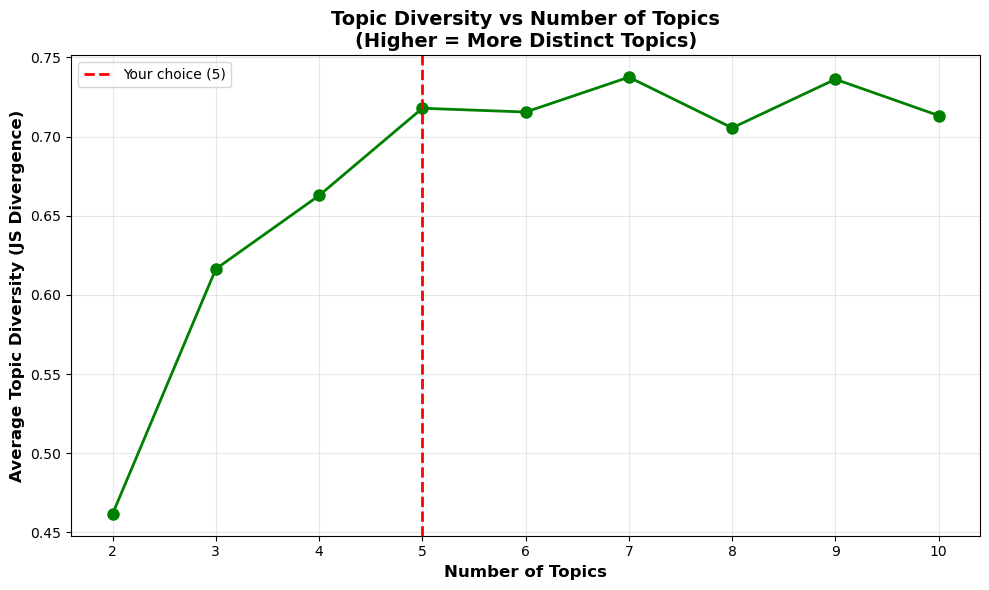

In [8]:
from scipy.spatial.distance import jensenshannon

def topic_diversity_score(model, num_topics):
    """Calculate average pairwise distance between topics"""
    topic_distributions = []
    vocab_size = len(model.id2word)
    
    for topic_id in range(num_topics):
        topic_dist = np.zeros(vocab_size)
        for word_id, prob in model.get_topic_terms(topic_id, topn=vocab_size):
            topic_dist[word_id] = prob
        topic_distributions.append(topic_dist)
    
    # Pairwise JS divergence
    distances = []
    for i in range(num_topics):
        for j in range(i + 1, num_topics):
            dist = jensenshannon(topic_distributions[i], topic_distributions[j])
            distances.append(dist)
    
    return np.mean(distances), distances

# Calculate diversity for different topic counts
diversity_scores = []
for num_topics in tqdm (range(2, 11), desc="Topic diversity"):
    model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=20
    )
    avg_div, _ = topic_diversity_score(model, num_topics)
    diversity_scores.append(avg_div)



C:\Users\moham\AppData\Local\Temp\ipykernel_17840\2280119205.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


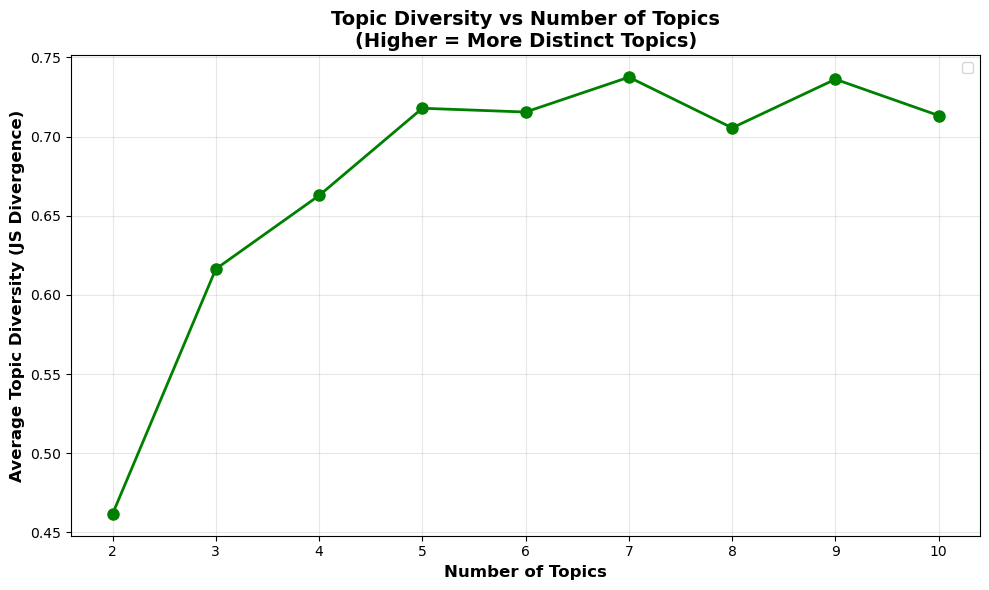

In [11]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), diversity_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Topics', fontsize=12, fontweight='bold')
plt.ylabel('Average Topic Diversity (JS Divergence)', fontsize=12, fontweight='bold')
plt.title('Topic Diversity vs Number of Topics\n(Higher = More Distinct Topics)', 
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/topic_diversity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()